# Лабораторная работа №5 по ТМО
## Перфильев Виктор Анатольевич
## Группа ИБМ3-65Б

#### Цель работы. Изучение ансамблей моделей машинного обучения.

## 1. Импорт библиотек и загрузка датасета

In [72]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
import time
from operator import itemgetter
import kagglehub

column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
df = pd.read_csv('housing.csv', sep='\s+', header=None, names=column_names)

df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


## 2. Проверка наличия пропусков и необходимости предобработки

In [73]:
print("\nПроверка на пропуски:")
print(df.isnull().sum().sum(), "пропусков найдено")


Проверка на пропуски:
0 пропусков найдено


## 3. Преобразование целевой переменной
#### В качестве целевой переменной выберем MEDV, вернее создадим новую переменную target. Если цена жилья больше, чем медиана столбца MEDV, то 1, если меньше, то 0.

In [74]:
# Cчитаем медиану и добавляем целевую переменную
threshold = df['MEDV'].median()  # примерно 21.2
df['target'] = (df['MEDV'] > threshold).astype(int)

X = df.drop(['MEDV', 'target'], axis=1)
y = df['target']

### График распределения классов

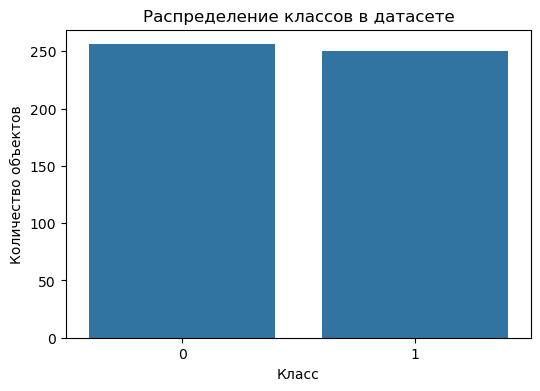

Распределение классов:
target
0    256
1    250
Name: count, dtype: int64


In [75]:
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df)
plt.title('Распределение классов в датасете')
plt.xlabel('Класс')
plt.ylabel('Количество объектов')
plt.show()

print("Распределение классов:")
print(df['target'].value_counts())

### Тепловая карта корреляций наиболее значимых признаков

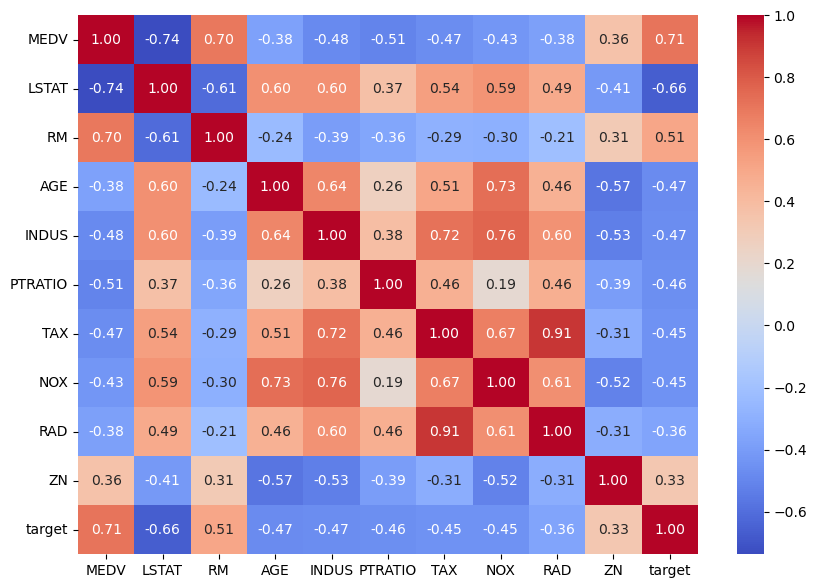

In [76]:
corr_with_target = df.corr(numeric_only=True)['target'].drop('target').abs().sort_values(ascending=False)
top_features = corr_with_target.head(10).index.tolist()

plt.figure(figsize=(10, 7))
sns.heatmap(df[top_features + ['target']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

## 4. Разделение выборки на обучающую и тестовую

In [77]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Обучающая выборка: {X_train.shape[0]} образцов ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Тестовая выборка: {X_test.shape[0]} образцов ({X_test.shape[0]/len(X)*100:.0f}%)")

Обучающая выборка: 354 образцов (70%)
Тестовая выборка: 152 образцов (30%)


## 5. Создание, обучение моделей и расчёт Accuracy

In [78]:
models = {
    'Random Forest (бэггинг)': RandomForestClassifier(n_estimators=100, random_state=42),
    'Extra Trees (бэггинг)': ExtraTreesClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    results.append({
        'Модель': name,
        'Accuracy': acc
    })

results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)
display(results_df)

,Модель,Accuracy
1,Extra Trees (бэггинг),0.888158
0,Random Forest (бэггинг),0.881579
3,Gradient Boosting,0.875000
2,AdaBoost,0.855263


## 6. Подробный отчёт о лучшей модели
#### Лучшей моделью по показателю Acuuracy была выбрана Extra Trees, так что дальше про неё

In [85]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Класс 0 (дешёвый)', 'Класс 1 (дорогой)']))


Classification Report:
                   precision    recall  f1-score   support

Класс 0 (дешёвый)       0.85      0.92      0.88        77
Класс 1 (дорогой)       0.91      0.83      0.87        75

         accuracy                           0.88       152
        macro avg       0.88      0.87      0.87       152
     weighted avg       0.88      0.88      0.87       152



### Матрица ошибок

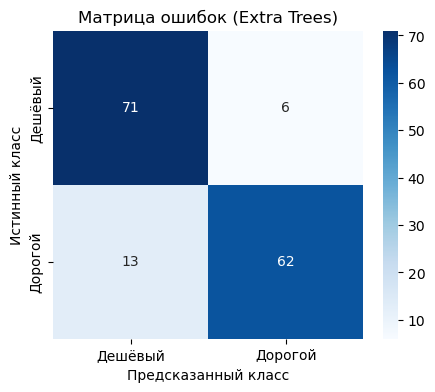

In [88]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Дешёвый', 'Дорогой'], 
            yticklabels=['Дешёвый', 'Дорогой'])
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок (Extra Trees)')
plt.show()

### Важность признаков для лучшей модели

,Признак,Важность
12,LSTAT,0.188832
5,RM,0.146608
6,AGE,0.094953
10,PTRATIO,0.091782
4,NOX,0.077487
9,TAX,0.075483
7,DIS,0.064272
11,B,0.061145
2,INDUS,0.058869
0,CRIM,0.054342


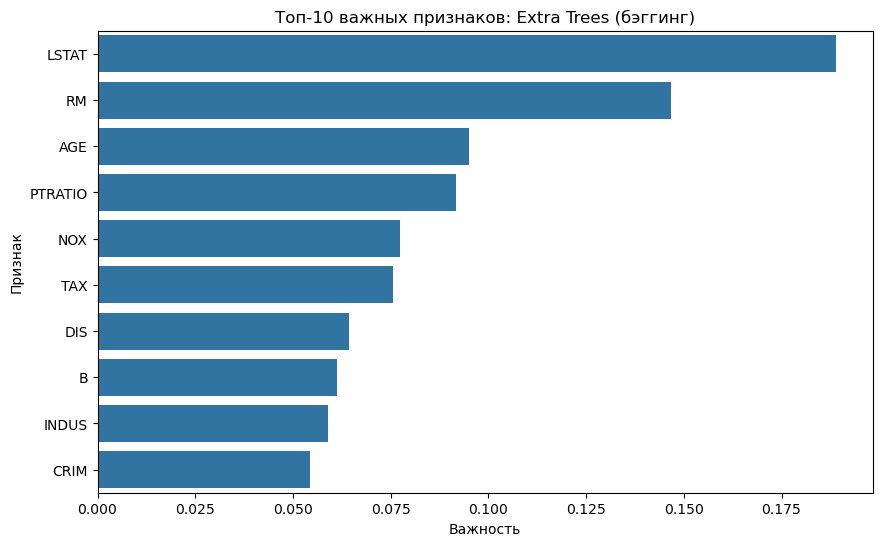

In [89]:
importances = pd.DataFrame({
    'Признак': X.columns,
    'Важность': best_model.feature_importances_
}).sort_values(by='Важность', ascending=False)

display(importances.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(data=importances.head(10), x='Важность', y='Признак')
plt.title(f'Топ-10 важных признаков: {best_model_name}')
plt.show()

## Вывод
#### Лучшей моделью по метрике Accuracy оказалась Extra Trees. При этом все ансамблевые модели (случайный лес, AdaBoost, градиентный бустинг) показали высокое качество классификации на датасете Boston Housing. Модель Extra Trees также позволила оценить важность признаков и визуализировать структуру отдельных деревьев.